In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 全局设置（中文+样式）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
order_path = r'orders.csv'
user_path = r'users.csv'
product_path = r'products.csv'

df_orders = pd.read_csv(order_path, encoding='utf-8', parse_dates=['下单时间'])
df_users = pd.read_csv(user_path, encoding='utf-8', parse_dates=['注册时间'])
df_products = pd.read_csv(product_path, encoding='utf-8')

In [4]:
df_orders

,订单号,用户ID,商品ID,下单时间,支付金额(元),城市
0,ORD001,U001,P001,2024-05-01 08:30:00,2999,北京
1,ORD002,U002,P002,2024-05-01 09:10:00,199,上海
2,ORD003,U003,P003,2024-05-01 10:00:00,318,广州
3,ORD004,U004,P004,2024-05-02 11:20:00,99,深圳
4,ORD005,U005,P001,2024-05-02 14:00:00,2999,北京


In [5]:
df_users

,用户ID,姓名,性别,年龄,注册时间
0,U001,张三,男,25,2024-01-10
1,U002,李四,女,32,2024-02-15
2,U003,王五,男,28,2024-01-20
3,U004,赵六,女,40,2024-03-05
4,U006,孙七,男,35,2024-04-12


In [6]:
df_products

,商品ID,商品名称,品类,单价(元),供应商
0,P001,智能手机,数码,2999,供应商A
1,P002,无线耳机,数码,199,供应商B
2,P003,纯棉卫衣,服饰,159,供应商C
3,P004,智能水杯,家居,99,供应商A
4,P005,机械键盘,数码,299,供应商B


In [7]:
df_order_user = pd.merge(
    df_orders,
    df_users,
    on='用户ID',        # 关联字段
    how='inner'        # 内连接：仅保留双方都有的用户ID
)

df_order_user

,订单号,用户ID,商品ID,下单时间,支付金额(元),城市,姓名,性别,年龄,注册时间
0,ORD001,U001,P001,2024-05-01 08:30:00,2999,北京,张三,男,25,2024-01-10
1,ORD002,U002,P002,2024-05-01 09:10:00,199,上海,李四,女,32,2024-02-15
2,ORD003,U003,P003,2024-05-01 10:00:00,318,广州,王五,男,28,2024-01-20
3,ORD004,U004,P004,2024-05-02 11:20:00,99,深圳,赵六,女,40,2024-03-05


In [8]:
df_all = pd.merge(
    df_order_user,
    df_products,
    on='商品ID',
    how='left'         # 左连接：保留订单表全部数据，商品表无匹配则补NaN
)

df_all

,订单号,用户ID,商品ID,下单时间,支付金额(元),城市,姓名,性别,年龄,注册时间,商品名称,品类,单价(元),供应商
0,ORD001,U001,P001,2024-05-01 08:30:00,2999,北京,张三,男,25,2024-01-10,智能手机,数码,2999,供应商A
1,ORD002,U002,P002,2024-05-01 09:10:00,199,上海,李四,女,32,2024-02-15,无线耳机,数码,199,供应商B
2,ORD003,U003,P003,2024-05-01 10:00:00,318,广州,王五,男,28,2024-01-20,纯棉卫衣,服饰,159,供应商C
3,ORD004,U004,P004,2024-05-02 11:20:00,99,深圳,赵六,女,40,2024-03-05,智能水杯,家居,99,供应商A


In [9]:
df_products_new = pd.DataFrame(
    {
        '商品ID': ['P006', 'P007'],
        '商品名称': ['运动跑鞋', '厨房刀具'],
        '品类': ['服饰', '家居'],
        '单价(元)': [399, 129],
        '供应商': ['供应商C', '供应商A']
    }
)

df_products_new

,商品ID,商品名称,品类,单价(元),供应商
0,P006,运动跑鞋,服饰,399,供应商C
1,P007,厨房刀具,家居,129,供应商A


In [10]:
df_products

,商品ID,商品名称,品类,单价(元),供应商
0,P001,智能手机,数码,2999,供应商A
1,P002,无线耳机,数码,199,供应商B
2,P003,纯棉卫衣,服饰,159,供应商C
3,P004,智能水杯,家居,99,供应商A
4,P005,机械键盘,数码,299,供应商B


In [11]:
df_products_all = pd.concat([df_products, df_products_new],  # 纵向拼接
    ignore_index=True               # 重置索引
)

df_products_all

,商品ID,商品名称,品类,单价(元),供应商
0,P001,智能手机,数码,2999,供应商A
1,P002,无线耳机,数码,199,供应商B
2,P003,纯棉卫衣,服饰,159,供应商C
3,P004,智能水杯,家居,99,供应商A
4,P005,机械键盘,数码,299,供应商B
5,P006,运动跑鞋,服饰,399,供应商C
6,P007,厨房刀具,家居,129,供应商A


In [12]:
df_users_idx = df_users.set_index('用户ID')  # 设置用户ID为索引
df_orders_idx = df_orders.set_index('用户ID')
df_join = df_orders_idx.join(df_users_idx[['姓名', '年龄']], how='left')

df_join

,订单号,商品ID,下单时间,支付金额(元),城市,姓名,年龄
用户ID,,,,,,,
U001,ORD001,P001,2024-05-01 08:30:00,2999,北京,张三,25.0
U002,ORD002,P002,2024-05-01 09:10:00,199,上海,李四,32.0
U003,ORD003,P003,2024-05-01 10:00:00,318,广州,王五,28.0
U004,ORD004,P004,2024-05-02 11:20:00,99,深圳,赵六,40.0
U005,ORD005,P001,2024-05-02 14:00:00,2999,北京,NaN,NaN


In [13]:
df_users_idx

,姓名,性别,年龄,注册时间
用户ID,,,,
U001,张三,男,25,2024-01-10
U002,李四,女,32,2024-02-15
U003,王五,男,28,2024-01-20
U004,赵六,女,40,2024-03-05
U006,孙七,男,35,2024-04-12


In [14]:
df_orders_idx

,订单号,商品ID,下单时间,支付金额(元),城市
用户ID,,,,,
U001,ORD001,P001,2024-05-01 08:30:00,2999,北京
U002,ORD002,P002,2024-05-01 09:10:00,199,上海
U003,ORD003,P003,2024-05-01 10:00:00,318,广州
U004,ORD004,P004,2024-05-02 11:20:00,99,深圳
U005,ORD005,P001,2024-05-02 14:00:00,2999,北京


In [15]:
df_all

,订单号,用户ID,商品ID,下单时间,支付金额(元),城市,姓名,性别,年龄,注册时间,商品名称,品类,单价(元),供应商
0,ORD001,U001,P001,2024-05-01 08:30:00,2999,北京,张三,男,25,2024-01-10,智能手机,数码,2999,供应商A
1,ORD002,U002,P002,2024-05-01 09:10:00,199,上海,李四,女,32,2024-02-15,无线耳机,数码,199,供应商B
2,ORD003,U003,P003,2024-05-01 10:00:00,318,广州,王五,男,28,2024-01-20,纯棉卫衣,服饰,159,供应商C
3,ORD004,U004,P004,2024-05-02 11:20:00,99,深圳,赵六,女,40,2024-03-05,智能水杯,家居,99,供应商A


In [16]:
df_all['供应商'] = df_all['供应商'].fillna('未知')

In [17]:
df_all['年龄段'] = df_all['年龄'].apply(lambda x: '20-30岁' if 20<=x<=30 else '30岁以上')
df_all

,订单号,用户ID,商品ID,下单时间,支付金额(元),城市,姓名,性别,年龄,注册时间,商品名称,品类,单价(元),供应商,年龄段
0,ORD001,U001,P001,2024-05-01 08:30:00,2999,北京,张三,男,25,2024-01-10,智能手机,数码,2999,供应商A,20-30岁
1,ORD002,U002,P002,2024-05-01 09:10:00,199,上海,李四,女,32,2024-02-15,无线耳机,数码,199,供应商B,30岁以上
2,ORD003,U003,P003,2024-05-01 10:00:00,318,广州,王五,男,28,2024-01-20,纯棉卫衣,服饰,159,供应商C,20-30岁
3,ORD004,U004,P004,2024-05-02 11:20:00,99,深圳,赵六,女,40,2024-03-05,智能水杯,家居,99,供应商A,30岁以上


In [18]:
gender_analysis = df_all.groupby('性别').agg({'支付金额(元)': ['sum', 'mean', 'count']}).round(2)
gender_analysis.columns = ['消费总额', '平均消费', '订单数']

gender_analysis

,消费总额,平均消费,订单数
性别,,,
女,298,149.0,2
男,3317,1658.5,2


In [19]:
category_analysis = df_all.groupby('品类').agg({'订单号': 'count','支付金额(元)': 'sum'}).rename(columns={'订单号': '订单数'}).round(2)

category_analysis

,订单数,支付金额(元)
品类,,
家居,1,99
数码,2,3198
服饰,1,318


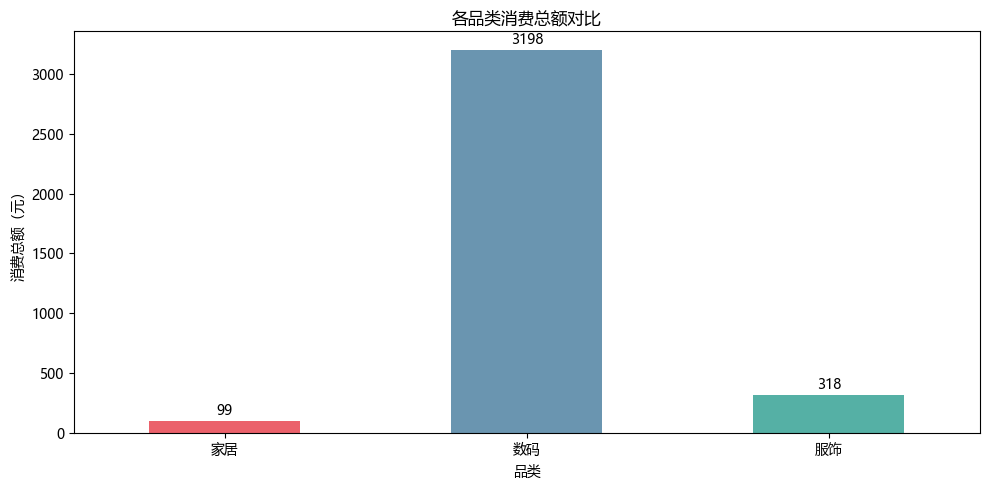

In [20]:
plt.figure(figsize=(10, 5))
category_analysis['支付金额(元)'].plot(
    kind='bar', color=['#E63946', '#457B9D', '#2A9D8F'], alpha=0.8)
plt.title('各品类消费总额对比')
plt.xlabel('品类')
plt.ylabel('消费总额（元）')
plt.xticks(rotation=0)
for i, v in enumerate(category_analysis['支付金额(元)']):
    plt.text(i, v+50, f'{v:.0f}', ha='center')
plt.tight_layout()
plt.show()

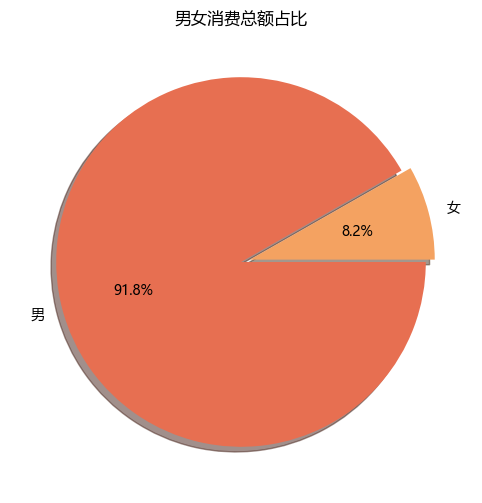

In [21]:
plt.figure(figsize=(8, 6))
plt.pie(
    gender_analysis['消费总额'],
    labels=gender_analysis.index,
    autopct='%1.1f%%',
    colors=['#F4A261', '#E76F51'],
    explode=(0.05, 0),
    shadow=True)
plt.title('男女消费总额占比')
plt.show()

In [22]:
df_all.to_excel('多表合并全量数据.xlsx', index=False)
gender_analysis.to_excel('性别消费分析.xlsx')
category_analysis.to_excel('品类消费分析.xlsx')
print("\n6. 合并及分析结果已导出为Excel文件！")


6. 合并及分析结果已导出为Excel文件！
